# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# HHL Algorithm (Harrow-Hassidim-Lloyd)

/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_76310/2807633593.py:33: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_clock_qubits, inverse=True, do_swaps=True).to_gate()
/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_76310/2807633593.py:45: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_clock_qubits, inverse=False, do_swaps=True).to_gate()


HHL Algorithm Structural Analysis

Clock qubits: 2 | Target system: 2x2 | Total qubits: 4


1. Circuit Visualisation

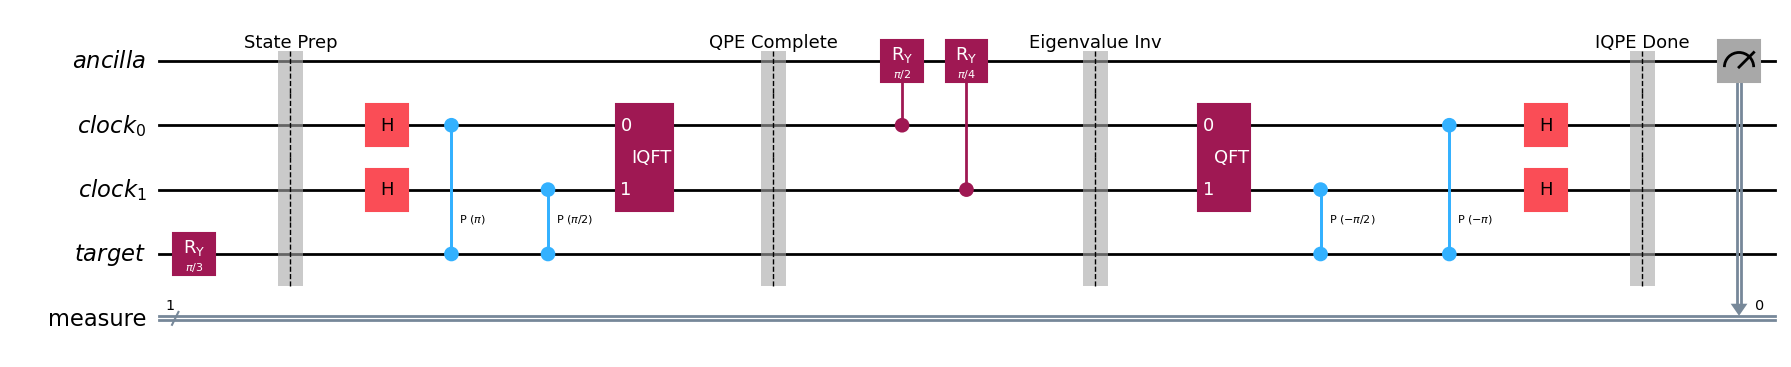

2. Unitary Evolution

The 8x8 unitary matrix describing the structural circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


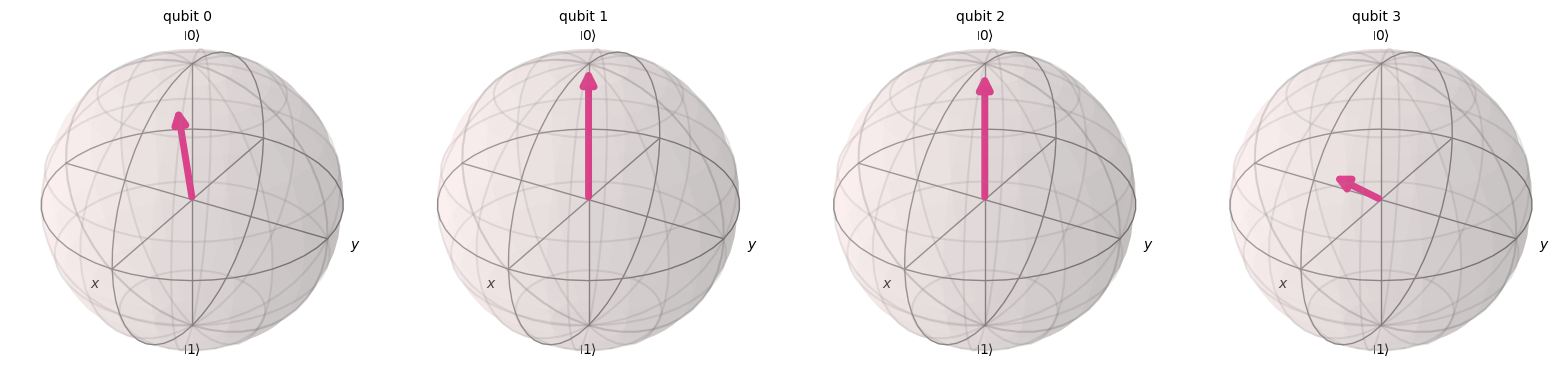


State prior to measurement (Q-Sphere):


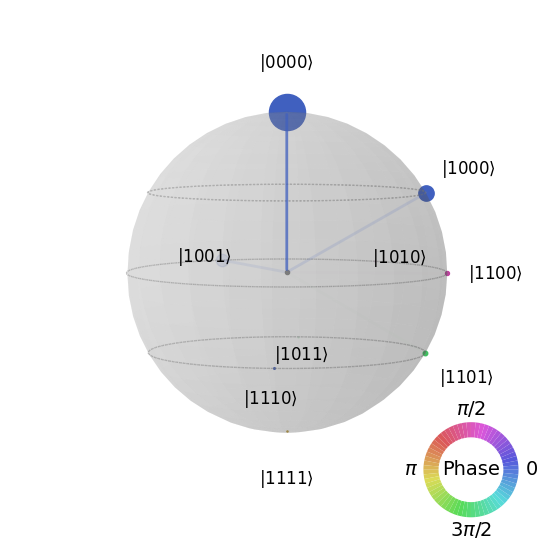

5. Measurement Analysis (Ancilla Post-Selection)

Raw measurement counts (Ancilla state 0 vs 1): {'1': 123, '0': 901}


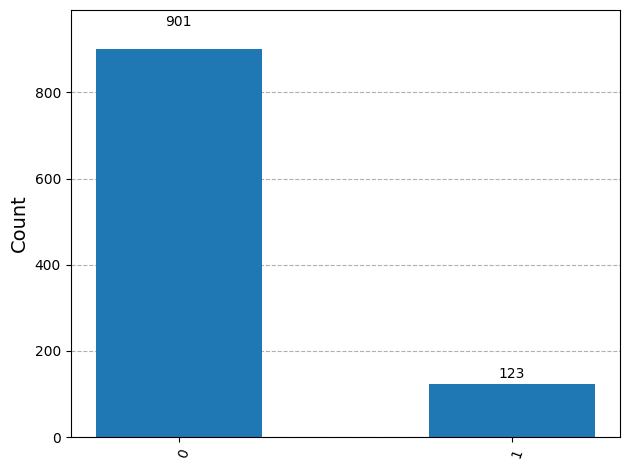


Post-Selection Success Rate: 12.01% of shots successfully inverted the eigenvalue onto the ancilla.


In [65]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
num_clock_qubits = 2

# 1. Set up Registers & Circuit
ancilla = QuantumRegister(1, name='ancilla')
clock = QuantumRegister(num_clock_qubits, name='clock')
target = QuantumRegister(1, name='target') # 2x2 system
c = ClassicalRegister(1, name='measure')

qc = QuantumCircuit(ancilla, clock, target, c)

# 2. State Preparation U_b (Loading vector b into target register)
qc.ry(np.pi/3, target[0])
qc.barrier(label="State Prep")

# 3. Quantum Phase Estimation (QPE)
qc.h(clock)
# Controlled Hamiltonian simulation placeholder: C-U(e^(iAt))
for i in range(num_clock_qubits):
    qc.cp(np.pi / (2**i), clock[i], target[0]) 
    
# Apply Inverse QFT to clock register
iqft = QFT(num_clock_qubits, inverse=True, do_swaps=True).to_gate()
iqft.name = "IQFT"
qc.append(iqft, clock)
qc.barrier(label="QPE Complete")

# 4. Controlled Eigenvalue Inversion (Conditional Rotation on Ancilla)
# Rotations scaled inversely to the eigenvalues represented by the clock register
qc.cry(np.pi/2, clock[0], ancilla[0])
qc.cry(np.pi/4, clock[1], ancilla[0])
qc.barrier(label="Eigenvalue Inv")

# 5. Uncomputation / Inverse QPE (Reverse QPE steps)
qft = QFT(num_clock_qubits, inverse=False, do_swaps=True).to_gate()
qft.name = "QFT"
qc.append(qft, clock)

for i in reversed(range(num_clock_qubits)):
    qc.cp(-np.pi / (2**i), clock[i], target[0])
qc.h(clock)
qc.barrier(label="IQPE Done")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 6. Post-selection Measurement (Measure ancilla)
qc.measure(ancilla, c)

# 7. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown("HHL Algorithm Structural Analysis"))
print(f"Clock qubits: {num_clock_qubits} | Target system: 2x2 | Total qubits: {qc.num_qubits}")

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
total_qubits = qc.num_qubits - 1  # Excluding classical register
if total_qubits <= 4:
    print(f"The {2**total_qubits}x{2**total_qubits} unitary matrix describing the structural circuit:")
    display(array_to_latex(unitary.data, prefix="U_{HHL} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {total_qubits} qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis (Ancilla Post-Selection)"))
counts = result.get_counts()
print(f"Raw measurement counts (Ancilla state 0 vs 1): {counts}")
display(plot_histogram(counts))

# Verification note
success_shots = counts.get('1', 0)
print(f"\nPost-Selection Success Rate: {(success_shots / 1024) * 100:.2f}% of shots successfully inverted the eigenvalue onto the ancilla.")